In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

sns.set(style='whitegrid')


In [3]:
df=pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
x=df.iloc[:, [3,4]].values

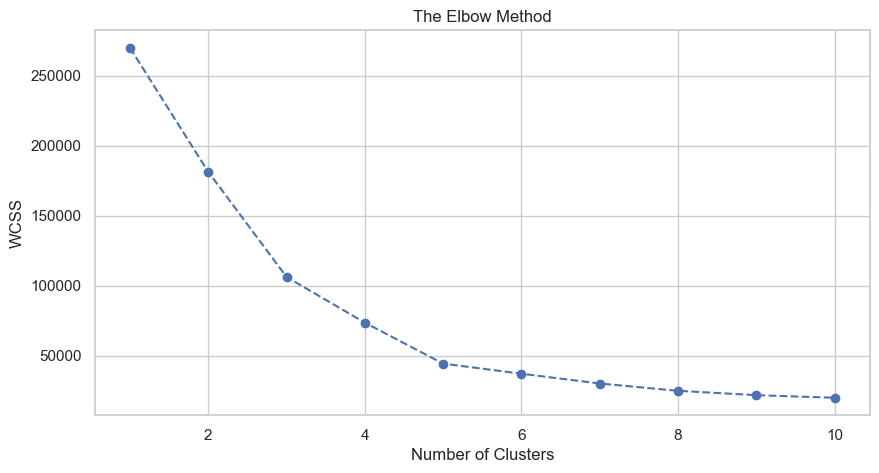

In [5]:
WCSS = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42,n_init=10)
    kmeans.fit(x)
    WCSS.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), WCSS, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [6]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(x)

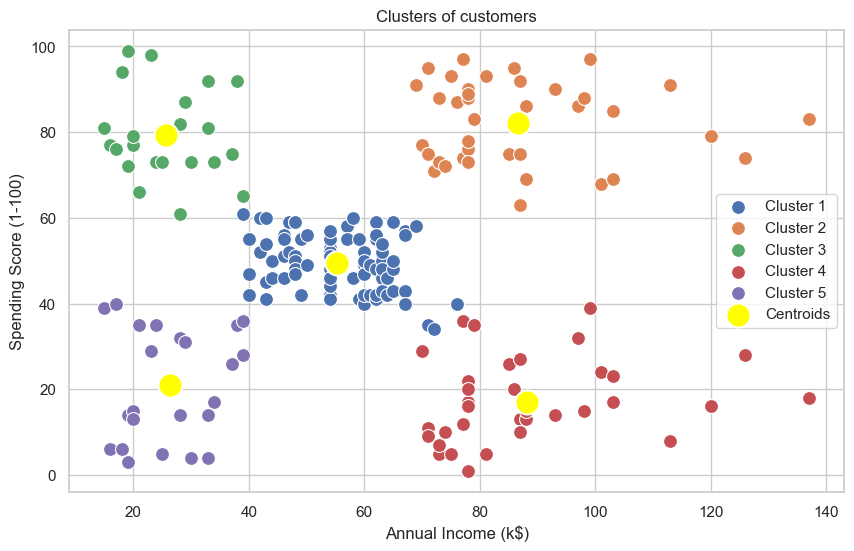

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x[y_kmeans == 0, 0], y=x[y_kmeans == 0, 1], s=100, label='Cluster 1')
sns.scatterplot(x=x[y_kmeans == 1, 0], y=x[y_kmeans == 1, 1], s=100, label='Cluster 2')
sns.scatterplot(x=x[y_kmeans == 2, 0], y=x[y_kmeans == 2, 1], s=100, label='Cluster 3')
sns.scatterplot(x=x[y_kmeans == 3, 0], y=x[y_kmeans == 3, 1], s=100, label='Cluster 4')
sns.scatterplot(x=x[y_kmeans == 4, 0], y=x[y_kmeans == 4, 1], s=100, label='Cluster 5')
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], s=300, color='yellow', label='Centroids')
plt.title('Clusters of customers')      
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [11]:
def classify_customer():
    try:
        print("---MARKET SEGMENTATION TOOL---")
        income=int(input("Enter annual income in k$ (eg:30): "))
        Spending=int(input("Enter Spending score 1-100 (eg:20): "))
        cluster=kmeans.predict([[income, Spending]])[0]

        cluster_names={
                0: "Sensible (High income, low Spent)",
                1: "Standard (Average income, Average Spending)",
                2: "Target (High income, high Spending)",
                3: "Careful (Low income, High Spending)",
                4: "Careless (Low income, Low Spending)"
        }
        print("\n" + "-" * 40)
        print(f"Result: The customer belongs to cluster {cluster + 1}")
        print(f"Segment: {cluster_names[cluster]}")
        print("-" * 40)
    except ValueError:
        print("Invalid input. please enter numeric values for income and Spending score.")
#run the classification tool
classify_customer()

---MARKET SEGMENTATION TOOL---

----------------------------------------
Result: The customer belongs to cluster 5
Segment: Careless (Low income, Low Spending)
----------------------------------------
